# Drug-Disease-Target Database Exploration

This notebook explores the database containing information about:
- **Drugs**: Known drugs with their targets and associated diseases
- **Diseases**: Disease information with ICD codes and associated genes/targets
- **Targets**: Gene targets with their roles, mechanisms, and associations
- **Associations**: Relationships between drugs, diseases, and targets

## Database Files
1. `drug_target_disease.csv` - Drug-target-disease associations
2. `causal_gene_disease.csv` - Causal gene-disease relationships
3. `onco_genes.csv` - Oncogene and tumor suppressor gene information
4. `target_priority.csv` - Target priority scores for diseases
5. `disease_target_by_source.csv` - Disease-target associations by source
6. `disease_target_overall.csv` - Overall disease-target associations
7. `protein_info.csv` - Protein information
8. `mount_sinai_drug_disease.csv` - Mount Sinai EHR drug-disease associations
9. `uk_biobank_drug_disease.csv` - UK Biobank EHR drug-disease associations
10. `drug_response_crispr_correlation.csv` - Drug response CRISPR correlations
11. `DrugTargetMetrics/` - Drug-target binding affinity and selectivity metrics


In [1]:
import sys
sys.path.insert(0, '..')
import os
os.chdir('..')

# Import necessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')

# Set plotting style
plt.style.use('seaborn-v0_8')
sns.set_palette("husl")

# Import our database query module
from agent.database_query_module import DrugDiseaseTargetDB, load_database

print("Libraries imported successfully!")
print(f"Pandas version: {pd.__version__}")
print(f"NumPy version: {np.__version__}")

Libraries imported successfully!
Pandas version: 2.3.1
NumPy version: 1.26.4


## 1. Load the Database

Let's load the database and see what information is available.

In [2]:
# Load the database
# Set load_full_data=True to load complete datasets (default)
# Set load_full_data=False to sample large files for faster loading
db = load_database("Database", load_full_data=True)

# Get database information
db_info = db.get_database_info()
print("=" * 60)
print("DATABASE SUMMARY")
print("=" * 60)
for name, info in db_info.items():
    print(f"\n{name.upper().replace('_', ' ')}")
    print(f"  Rows: {info['rows']:,}")
    print(f"  Columns ({info['column_count']}): {', '.join(info['columns'][:10])}")
    if len(info['columns']) > 10:
        print(f"    ... and {len(info['columns']) - 10} more columns")


Loading database files...
Note: Loading full data from all files (this may take time for large files).
Loading drug_target_disease.csv...
  Loaded 276,147 records
Loading causal_gene_disease.csv...
  Loaded 13,008 records
Loading onco_genes.csv...
  Loaded 1,029 records
Loading target_priority.csv...
  Loaded 886,087 records
Loading full data from disease_target_by_source.csv (file is 844.4 MB, this may take a while)...
  Loaded 886,087 records
Loading full data from disease_target_overall.csv (file is 814.4 MB, this may take a while)...
  Loaded 867,363 records
Loading mount_sinai_drug_disease.csv...
  Loaded 41,120 records
Loading uk_biobank_drug_disease.csv...
  Loaded 693 records
Loading drug_response_crispr_correlation.csv...
  Loaded 464,820 records
Loading drug_selectivity_metrics.csv...
  Loaded 14,981 records
Loading drug_umap_clustering.csv...
  Loaded 14,981 records
Loading target_binding_stats.csv...
  Loaded 1,068 records
Database loading complete!

DATABASE SUMMARY

DRUG 

## 2. Database Statistics

Let's get overall statistics about the database.

In [3]:
# Get overall statistics
stats = db.get_statistics()

print("=" * 60)
print("DATABASE STATISTICS")
print("=" * 60)

if 'drugs' in stats:
    print("\n📊 DRUG-TARGET-DISEASE ASSOCIATIONS")
    print(f"  Total records: {stats['drugs']['total_records']:,}")
    print(f"  Unique drugs: {stats['drugs']['unique_drugs']:,}")
    print(f"  Unique targets (genes): {stats['drugs']['unique_targets']:,}")
    print(f"  Unique diseases: {stats['drugs']['unique_diseases']:,}")
    if stats['drugs']['phases']:
        print(f"  Clinical trial phases: {stats['drugs']['phases']}")

if 'causal_associations' in stats:
    print("\n🧬 CAUSAL GENE-DISEASE ASSOCIATIONS")
    print(f"  Total records: {stats['causal_associations']['total_records']:,}")
    print(f"  Unique genes: {stats['causal_associations']['unique_genes']:,}")
    print(f"  Unique diseases: {stats['causal_associations']['unique_diseases']:,}")
    if stats['causal_associations']['causal_types']:
        print(f"  Causal types: {stats['causal_associations']['causal_types']}")

if 'oncogenes' in stats:
    print("\n🎯 ONCOGENE INFORMATION")
    print(f"  Total genes: {stats['oncogenes']['total_genes']:,}")
    if stats['oncogenes']['role_distribution']:
        print(f"  Role distribution: {stats['oncogenes']['role_distribution']}")


DATABASE STATISTICS

📊 DRUG-TARGET-DISEASE ASSOCIATIONS
  Total records: 276,147
  Unique drugs: 4,274
  Unique targets (genes): 1,520
  Unique diseases: 2,684
  Clinical trial phases: {2.0: 114714, 1.0: 72059, 3.0: 60097, 4.0: 21909, 0.5: 7368}

🧬 CAUSAL GENE-DISEASE ASSOCIATIONS
  Total records: 13,008
  Unique genes: 3,400
  Unique diseases: 3,859
  Causal types: {'CausalMutation': 9441, 'GermlineCausalMutation': 3435, 'SomaticCausalMutation': 132}

🎯 ONCOGENE INFORMATION
  Total genes: 1,029
  Role distribution: {'Oncogene': 485, 'TSG': 404, 'Both': 140}


## 3. Explore Drug Data

Let's examine the drug-target-disease associations in detail.

In [4]:
# Get a sample of drug data
if 'drug_target_disease' in db.dfs:
    drug_df = db.dfs['drug_target_disease']
    
    print("=" * 60)
    print("DRUG-TARGET-DISEASE DATA SAMPLE")
    print("=" * 60)
    print(f"\nShape: {drug_df.shape}")
    print(f"\nColumns: {list(drug_df.columns)}")
    print("\nFirst few rows:")
    display(drug_df.head(10))
    
    print("\n" + "=" * 60)
    print("DATA TYPES")
    print("=" * 60)
    print(drug_df.dtypes)
    
    print("\n" + "=" * 60)
    print("MISSING VALUES")
    print("=" * 60)
    missing = drug_df.isnull().sum()
    missing_pct = (missing / len(drug_df) * 100).round(2)
    missing_df = pd.DataFrame({
        'Missing Count': missing,
        'Missing %': missing_pct
    })
    display(missing_df[missing_df['Missing Count'] > 0].sort_values('Missing Count', ascending=False))


DRUG-TARGET-DISEASE DATA SAMPLE

Shape: (276147, 12)

Columns: ['drugId', 'targetId', 'diseaseId', 'phase', 'status', 'Gene', 'mechanismOfAction', 'targetName', 'source', 'subject_label', 'ICD_Code', 'Status']

First few rows:


,drugId,targetId,diseaseId,phase,status,Gene,mechanismOfAction,targetName,source,subject_label,ICD_Code,Status
0,CHEMBL265502,ENSG00000113578,DOID_10113,3.0,NaN,FGF1,Acidic fibroblast growth factor inhibitor,Acidic fibroblast growth factor,NaN,NaN,NaN,Known Drug
1,CHEMBL413376,ENSG00000113578,DOID_10113,3.0,NaN,FGF1,Acidic fibroblast growth factor inhibitor,Acidic fibroblast growth factor,NaN,NaN,NaN,Known Drug
2,CHEMBL52440,ENSG00000147955,DOID_10113,1.0,Completed,SIGMAR1,Sigma opioid receptor agonist,Sigma opioid receptor,NaN,NaN,NaN,Known Drug
3,CHEMBL655,ENSG00000011677,DOID_10113,1.0,Completed,GABRA3,GABA-A receptor; anion channel positive allost...,GABA-A receptor; anion channel,NaN,NaN,NaN,Known Drug
4,CHEMBL655,ENSG00000113327,DOID_10113,1.0,Completed,GABRG2,GABA-A receptor; anion channel positive allost...,GABA-A receptor; anion channel,NaN,NaN,NaN,Known Drug
5,CHEMBL655,ENSG00000163285,DOID_10113,1.0,Completed,GABRG1,GABA-A receptor; anion channel positive allost...,GABA-A receptor; anion channel,NaN,NaN,NaN,Known Drug
6,CHEMBL655,ENSG00000182256,DOID_10113,1.0,Completed,GABRG3,GABA-A receptor; anion channel positive allost...,GABA-A receptor; anion channel,NaN,NaN,NaN,Known Drug
7,CHEMBL830,ENSG00000115758,DOID_10113,3.0,NaN,ODC1,Ornithine decarboxylase inhibitor,Ornithine decarboxylase,NaN,NaN,NaN,Known Drug
8,CHEMBL830,ENSG00000115758,DOID_10113,3.0,Completed,ODC1,Ornithine decarboxylase inhibitor,Ornithine decarboxylase,NaN,NaN,NaN,Known Drug
9,CHEMBL1201834,ENSG00000125538,DOID_13406,2.0,Completed,IL1B,Interleukin-1 beta inhibitor,Interleukin-1 beta,NaN,NaN,NaN,Known Drug



DATA TYPES
drugId                object
targetId              object
diseaseId             object
phase                float64
status                object
Gene                  object
mechanismOfAction     object
targetName            object
source                object
subject_label         object
ICD_Code              object
Status                object
dtype: object

MISSING VALUES


,Missing Count,Missing %
source,165483,59.93
subject_label,165483,59.93
ICD_Code,165483,59.93
status,14035,5.08


## 4. Explore Disease Data

Let's examine disease information and associations.

In [5]:
# Explore causal gene-disease associations
if 'causal_gene_disease' in db.dfs:
    causal_df = db.dfs['causal_gene_disease']
    
    print("=" * 60)
    print("CAUSAL GENE-DISEASE ASSOCIATIONS")
    print("=" * 60)
    print(f"\nShape: {causal_df.shape}")
    print(f"\nColumns: {list(causal_df.columns)}")
    print("\nFirst few rows:")
    display(causal_df.head(10))
    
    print("\n" + "=" * 60)
    print("TOP DISEASES BY GENE ASSOCIATIONS")
    print("=" * 60)
    disease_counts = causal_df['Disease Name'].value_counts().head(20)
    print(disease_counts)
    
    print("\n" + "=" * 60)
    print("TOP GENES BY DISEASE ASSOCIATIONS")
    print("=" * 60)
    gene_counts = causal_df['Gene'].value_counts().head(20)
    print(gene_counts)


CAUSAL GENE-DISEASE ASSOCIATIONS

Shape: (13008, 5)

Columns: ['Gene', 'ICD_Code', 'Source', 'CausalType', 'Disease Name']

First few rows:


,Gene,ICD_Code,Source,CausalType,Disease Name
0,SERPING1,R10,disgenet,CausalMutation,Abdominal Pain
1,HMBS,R10,disgenet,CausalMutation,Abdominal Pain
2,SH2B3,R10,disgenet,CausalMutation,Abdominal Pain
3,ATP1A3,R10,disgenet,CausalMutation,Abdominal Pain
4,STK11,R10,disgenet,CausalMutation,Abdominal Pain
5,MECP2,R10,disgenet,CausalMutation,Abdominal Pain
6,TMEM94,R10,disgenet,CausalMutation,Abdominal Pain
7,ATXN2,R10,disgenet,CausalMutation,Abdominal Pain
8,TRIP12,R10,disgenet,CausalMutation,Abdominal Pain
9,MTTP,E78,"orphanet , disgenet",GermlineCausalMutation,Abetalipoproteinemia



TOP DISEASES BY GENE ASSOCIATIONS
Disease Name
Muscle Hypotonia                                    232
Retinitis Pigmentosa                                192
Abnormalities, Multiple                             174
Seizure                                             141
Hearing Loss                                        126
Movement Disorders                                  120
Neoplasm, Ovarian                                    94
Joubert syndrome 1                                   76
Muscular Disease                                     69
Hereditary Neoplastic Syndrome                       64
Hearing Loss, Sensorineural                          54
MELAS Syndrome                                       54
Dilated cardiomyopathy, familial                     51
Congenital Amauroses, Leber                          46
Myeloid Leukemias, Acute                             46
Deafness                                             46
Hypertelorism                                        41


## 5. Explore Target/Gene Data

Let's examine target and gene information.

ONCOGENE INFORMATION

Shape: (1029, 2)

Columns: ['Gene', 'Role']

First few rows:


,Gene,Role
0,ABL1,Oncogene
1,AKT1,Oncogene
2,ALK,Oncogene
3,AMER1,TSG
4,APC,TSG
5,AR,Oncogene
6,ARID1A,Both
7,ASXL1,TSG
8,ATM,TSG
9,ATRX,TSG



ROLE DISTRIBUTION
Role
Oncogene    485
TSG         404
Both        140
Name: count, dtype: int64


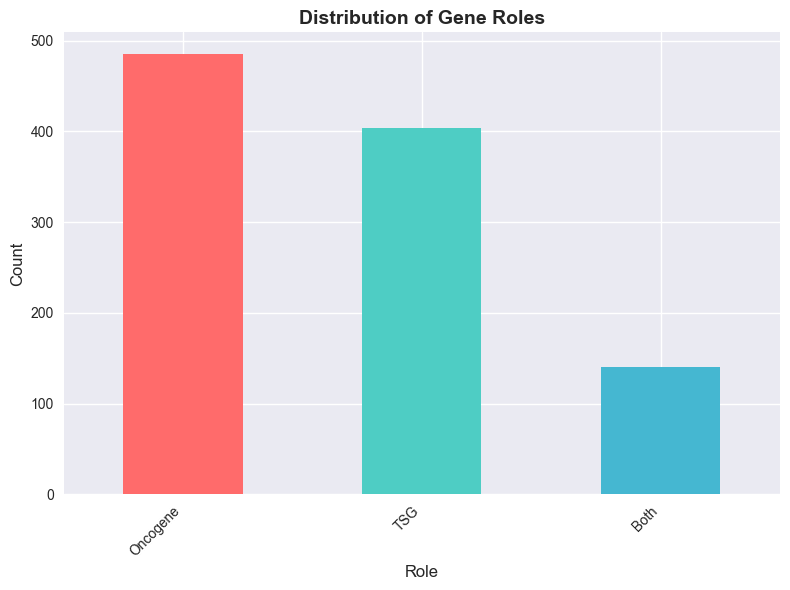

In [6]:
# Explore oncogene information
if 'onco_genes' in db.dfs:
    onco_df = db.dfs['onco_genes']
    
    print("=" * 60)
    print("ONCOGENE INFORMATION")
    print("=" * 60)
    print(f"\nShape: {onco_df.shape}")
    print(f"\nColumns: {list(onco_df.columns)}")
    print("\nFirst few rows:")
    display(onco_df.head(10))
    
    print("\n" + "=" * 60)
    print("ROLE DISTRIBUTION")
    print("=" * 60)
    role_counts = onco_df['Role'].value_counts()
    print(role_counts)
    
    # Visualize role distribution
    plt.figure(figsize=(8, 6))
    role_counts.plot(kind='bar', color=['#FF6B6B', '#4ECDC4', '#45B7D1'])
    plt.title('Distribution of Gene Roles', fontsize=14, fontweight='bold')
    plt.xlabel('Role', fontsize=12)
    plt.ylabel('Count', fontsize=12)
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    plt.show()


## 6. Example Queries

Let's demonstrate how to query the database for specific information.

In [7]:
# Example 1: Search for drugs targeting a specific gene (e.g., BRAF)
print("=" * 60)
print("EXAMPLE 1: Drugs targeting BRAF")
print("=" * 60)
braf_drugs = db.get_drugs_by_target("BRAF")
if not braf_drugs.empty:
    print(f"\nFound {len(braf_drugs)} drug-target associations for BRAF")
    display(braf_drugs[['drugId', 'targetName', 'mechanismOfAction', 'diseaseId', 'subject_label', 'phase', 'status']].head(10))
else:
    print("No drugs found for BRAF")


EXAMPLE 1: Drugs targeting BRAF

Found 826 drug-target associations for BRAF


,drugId,targetName,mechanismOfAction,diseaseId,subject_label,phase,status
198,CHEMBL1200485,Serine/threonine-protein kinase B-raf,Serine/threonine-protein kinase B-raf inhibitor,EFO_0000095,NaN,2.0,Terminated
1897,CHEMBL1200485,Serine/threonine-protein kinase B-raf,Serine/threonine-protein kinase B-raf inhibitor,EFO_0000182,NaN,1.0,"Active, not recruiting"
1901,CHEMBL1200485,Serine/threonine-protein kinase B-raf,Serine/threonine-protein kinase B-raf inhibitor,EFO_0000182,NaN,1.0,Completed
1906,CHEMBL1200485,Serine/threonine-protein kinase B-raf,Serine/threonine-protein kinase B-raf inhibitor,EFO_0000182,NaN,3.0,Completed
1994,CHEMBL1336,Serine/threonine-protein kinase B-raf,Serine/threonine-protein kinase B-raf inhibitor,EFO_0000182,NaN,0.5,Terminated
1997,CHEMBL1336,Serine/threonine-protein kinase B-raf,Serine/threonine-protein kinase B-raf inhibitor,EFO_0000182,NaN,1.0,"Active, not recruiting"
2007,CHEMBL1336,Serine/threonine-protein kinase B-raf,Serine/threonine-protein kinase B-raf inhibitor,EFO_0000182,NaN,1.0,Recruiting
2013,CHEMBL1336,Serine/threonine-protein kinase B-raf,Serine/threonine-protein kinase B-raf inhibitor,EFO_0000182,NaN,1.0,Suspended
2017,CHEMBL1336,Serine/threonine-protein kinase B-raf,Serine/threonine-protein kinase B-raf inhibitor,EFO_0000182,NaN,1.0,Unknown status
2029,CHEMBL1336,Serine/threonine-protein kinase B-raf,Serine/threonine-protein kinase B-raf inhibitor,EFO_0000182,NaN,2.0,Completed


In [8]:
# Example 2: Search for diseases associated with a specific gene
print("=" * 60)
print("EXAMPLE 2: Diseases associated with EGFR")
print("=" * 60)
egfr_diseases = db.get_diseases_by_gene("EGFR")
if not egfr_diseases.empty:
    print(f"\nFound {len(egfr_diseases)} disease associations for EGFR")
    # Get unique diseases
    if 'subject_label' in egfr_diseases.columns:
        unique_diseases = egfr_diseases[['subject_label', 'ICD_Code', 'diseaseId']].drop_duplicates()
        display(unique_diseases.head(10))
    else:
        display(egfr_diseases.head(10))
else:
    print("No diseases found for EGFR")


EXAMPLE 2: Diseases associated with EGFR

Found 910 disease associations for EGFR


,subject_label,ICD_Code,diseaseId
0,NaN,NaN,EFO_0000096
1,NaN,NaN,EFO_0000181
12,NaN,NaN,EFO_0000182
16,NaN,NaN,EFO_0000198
17,NaN,NaN,EFO_0000199
18,NaN,NaN,EFO_0000222
22,NaN,NaN,EFO_0000228
23,NaN,NaN,EFO_0000231
24,NaN,NaN,EFO_0000233
26,NaN,NaN,EFO_0000239


In [9]:
# Example 3: Get comprehensive information about a target
print("=" * 60)
print("EXAMPLE 3: Comprehensive information about TP53")
print("=" * 60)
tp53_info = db.get_target_info("TP53")
print(f"\nGene: {tp53_info['gene']}")
print(f"\nNumber of drugs: {len(tp53_info['drugs'])}")
print(f"Number of diseases: {len(tp53_info['diseases'])}")
print(f"Oncogene info: {tp53_info['onco_info']}")
print(f"Target priority records: {len(tp53_info['target_priority'])}")

if tp53_info['drugs']:
    print("\nSample drugs:")
    drugs_df = pd.DataFrame(tp53_info['drugs']).head(5)
    display(drugs_df)


EXAMPLE 3: Comprehensive information about TP53

Gene: TP53

Number of drugs: 80
Number of diseases: 105
Oncogene info: {'Gene': 'TP53', 'Role': 'Both'}
Target priority records: 526

Sample drugs:


,drugId,targetName,mechanismOfAction,diseaseId,phase,status
0,CHEMBL2219776,p53 mRNA,p53 mRNA antisense inhibitor,EFO_0000095,2.0,Terminated
1,CHEMBL2108280,p53 mRNA,p53 mRNA antisense inhibitor,EFO_0000198,1.0,Terminated
2,CHEMBL4091801,Tumour suppressor p53/oncoprotein Mdm2,Tumour suppressor p53/oncoprotein Mdm2 inhibitor,EFO_0000198,1.0,Recruiting
3,CHEMBL2402737,Tumour suppressor p53/oncoprotein Mdm2,Tumour suppressor p53/oncoprotein Mdm2 inhibitor,EFO_0000222,1.0,Completed
4,CHEMBL3125702,Tumour suppressor p53/oncoprotein Mdm2,Tumour suppressor p53/oncoprotein Mdm2 inhibitor,EFO_0000222,1.0,Terminated


In [10]:
# Example 4: Search for drugs by disease
print("=" * 60)
print("EXAMPLE 4: Drugs for cancer (searching by disease ID containing 'EFO_0000094' or 'MONDO')")
print("=" * 60)
# Search for cancer-related drugs
cancer_drugs = db.search_drugs(disease_id="EFO_0000094")
if not cancer_drugs.empty:
    print(f"\nFound {len(cancer_drugs)} drug associations")
    # Get unique drugs
    unique_drugs = cancer_drugs[['drugId', 'Gene', 'targetName', 'mechanismOfAction', 'phase']].drop_duplicates()
    print(f"Unique drug-target combinations: {len(unique_drugs)}")
    display(unique_drugs.head(10))
else:
    print("No drugs found")


EXAMPLE 4: Drugs for cancer (searching by disease ID containing 'EFO_0000094' or 'MONDO')

Found 163 drug associations
Unique drug-target combinations: 127


,drugId,Gene,targetName,mechanismOfAction,phase
29,CHEMBL1096882,POLD2,DNA polymerase (alpha/delta/epsilon),DNA polymerase (alpha/delta/epsilon) inhibitor,1.0
30,CHEMBL1096882,PRIM2,DNA polymerase (alpha/delta/epsilon),DNA polymerase (alpha/delta/epsilon) inhibitor,1.0
31,CHEMBL1096882,RRM1,Ribonucleoside-diphosphate reductase RR1,Ribonucleoside-diphosphate reductase RR1 inhib...,1.0
32,CHEMBL1096882,PRIM1,DNA polymerase (alpha/delta/epsilon),DNA polymerase (alpha/delta/epsilon) inhibitor,1.0
33,CHEMBL1200645,TOP2A,DNA topoisomerase II alpha,DNA topoisomerase II alpha inhibitor,2.0
34,CHEMBL1200751,PPAT,Amidophosphoribosyltransferase,Amidophosphoribosyltransferase inhibitor,1.0
35,CHEMBL1201438,IL2RA,Interleukin-2 receptor,Interleukin-2 receptor agonist,1.0
36,CHEMBL1201567,CSF3R,Granulocyte colony stimulating factor receptor,Granulocyte colony stimulating factor receptor...,2.0
37,CHEMBL1201587,CD52,CAMPATH-1 antigen,CAMPATH-1 antigen inhibitor,1.0
38,CHEMBL1425,PPAT,Amidophosphoribosyltransferase,Amidophosphoribosyltransferase inhibitor,1.0


## 7. Visualizations

Let's create some visualizations to better understand the data.

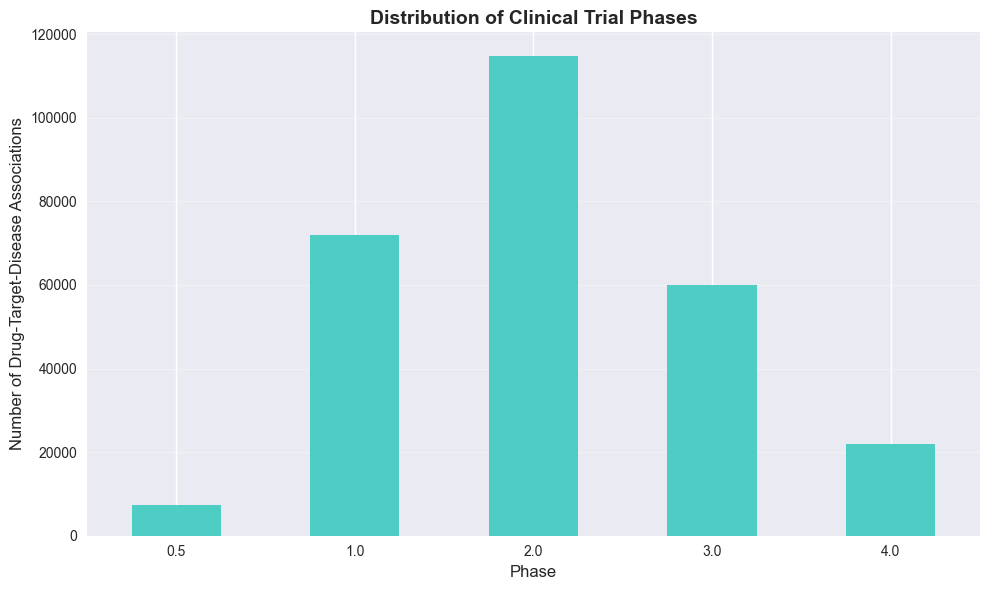

Total associations with phase information: 276,147


In [11]:
# Visualization 1: Clinical trial phases distribution
if 'drug_target_disease' in db.dfs:
    drug_df = db.dfs['drug_target_disease']
    
    if 'phase' in drug_df.columns:
        # Clean phase data
        phase_data = drug_df['phase'].dropna()
        phase_counts = phase_data.value_counts().sort_index()
        
        plt.figure(figsize=(10, 6))
        phase_counts.plot(kind='bar', color='#4ECDC4')
        plt.title('Distribution of Clinical Trial Phases', fontsize=14, fontweight='bold')
        plt.xlabel('Phase', fontsize=12)
        plt.ylabel('Number of Drug-Target-Disease Associations', fontsize=12)
        plt.xticks(rotation=0)
        plt.grid(axis='y', alpha=0.3)
        plt.tight_layout()
        plt.show()
        
        print(f"Total associations with phase information: {len(phase_data):,}")


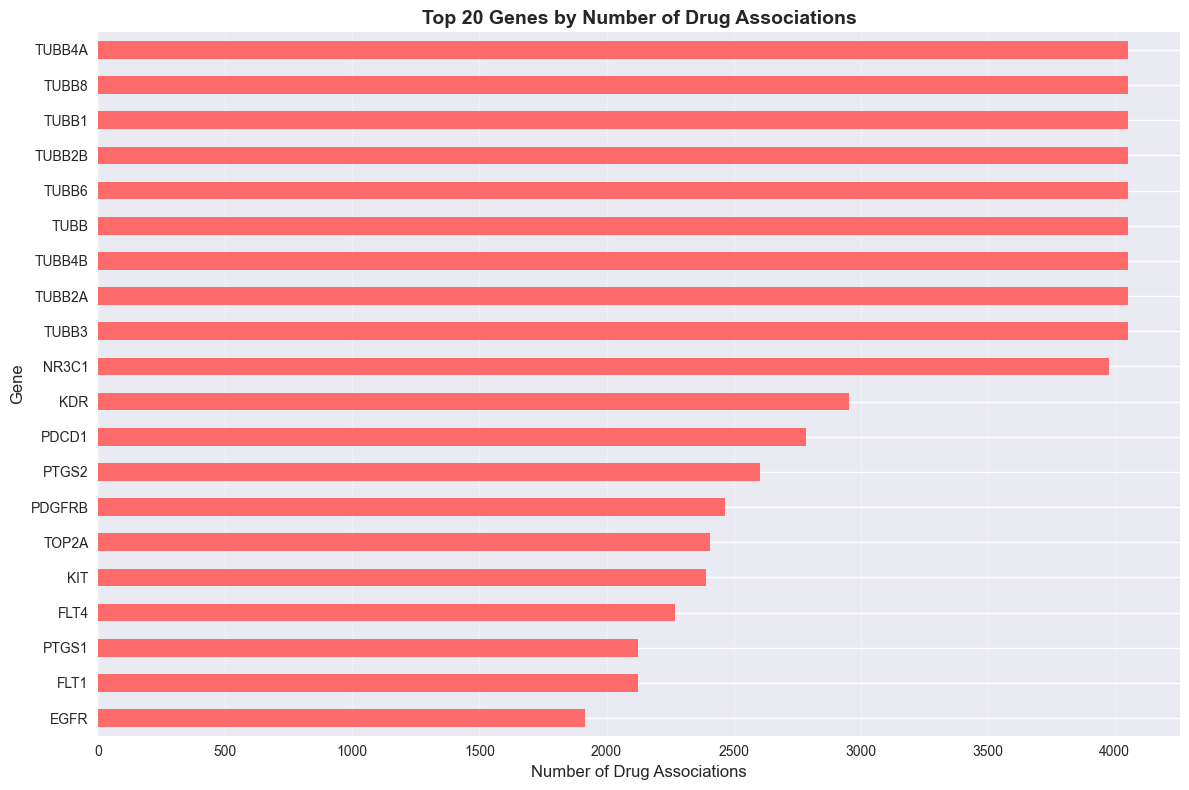

Top 10 genes:
Gene
TUBB4A    4054
TUBB8     4054
TUBB1     4054
TUBB2B    4054
TUBB6     4054
TUBB      4054
TUBB4B    4054
TUBB2A    4054
TUBB3     4054
NR3C1     3977
Name: count, dtype: int64


In [12]:
# Visualization 2: Top genes by number of drug associations
if 'drug_target_disease' in db.dfs:
    drug_df = db.dfs['drug_target_disease']
    
    if 'Gene' in drug_df.columns:
        gene_counts = drug_df['Gene'].value_counts().head(20)
        
        plt.figure(figsize=(12, 8))
        gene_counts.plot(kind='barh', color='#FF6B6B')
        plt.title('Top 20 Genes by Number of Drug Associations', fontsize=14, fontweight='bold')
        plt.xlabel('Number of Drug Associations', fontsize=12)
        plt.ylabel('Gene', fontsize=12)
        plt.gca().invert_yaxis()
        plt.grid(axis='x', alpha=0.3)
        plt.tight_layout()
        plt.show()
        
        print("Top 10 genes:")
        print(gene_counts.head(10))


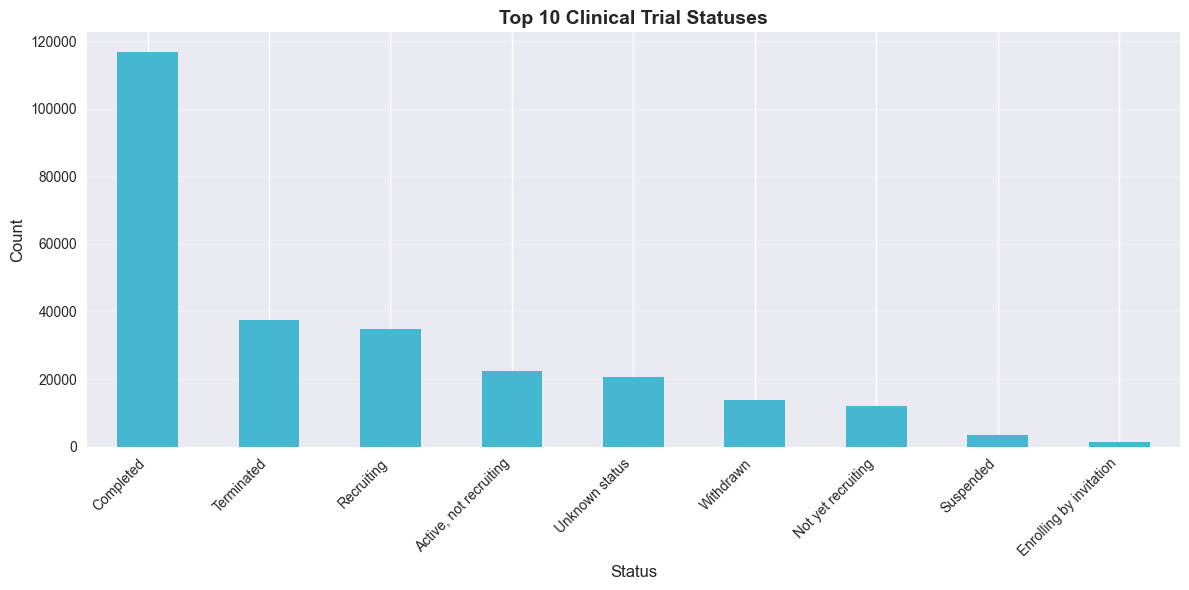

Status distribution:
status
Completed                  116801
Terminated                  37397
Recruiting                  34721
Active, not recruiting      22317
Unknown status              20496
Withdrawn                   13741
Not yet recruiting          11927
Suspended                    3329
Enrolling by invitation      1383
Name: count, dtype: int64


In [13]:
# Visualization 3: Trial status distribution
if 'drug_target_disease' in db.dfs:
    drug_df = db.dfs['drug_target_disease']
    
    if 'status' in drug_df.columns:
        status_data = drug_df['status'].dropna()
        status_counts = status_data.value_counts().head(10)
        
        plt.figure(figsize=(12, 6))
        status_counts.plot(kind='bar', color='#45B7D1')
        plt.title('Top 10 Clinical Trial Statuses', fontsize=14, fontweight='bold')
        plt.xlabel('Status', fontsize=12)
        plt.ylabel('Count', fontsize=12)
        plt.xticks(rotation=45, ha='right')
        plt.grid(axis='y', alpha=0.3)
        plt.tight_layout()
        plt.show()
        
        print("Status distribution:")
        print(status_counts)


## 8. Advanced Queries

Let's perform some more complex queries to understand associations.

In [14]:
# Advanced Query 1: Find drugs in Phase 3 or 4 (late-stage)
print("=" * 60)
print("ADVANCED QUERY 1: Late-stage drugs (Phase 3 or 4)")
print("=" * 60)
late_stage_drugs = db.search_drugs(phase=3.0)
late_stage_drugs_4 = db.search_drugs(phase=4.0)
all_late_stage = pd.concat([late_stage_drugs, late_stage_drugs_4], ignore_index=True).drop_duplicates()

if not all_late_stage.empty:
    print(f"\nFound {len(all_late_stage)} late-stage drug associations")
    print(f"Unique drugs: {all_late_stage['drugId'].nunique()}")
    print(f"Unique targets: {all_late_stage['Gene'].nunique()}")
    print(f"Unique diseases: {all_late_stage['diseaseId'].nunique()}")
    
    # Show top targets for late-stage drugs
    top_targets = all_late_stage['Gene'].value_counts().head(10)
    print("\nTop 10 targets in late-stage development:")
    print(top_targets)


ADVANCED QUERY 1: Late-stage drugs (Phase 3 or 4)

Found 82006 late-stage drug associations
Unique drugs: 2744
Unique targets: 1144
Unique diseases: 1790

Top 10 targets in late-stage development:
Gene
NR3C1     2022
PTGS2     1345
TUBB1     1130
TUBB8     1130
TUBB3     1130
TUBB2A    1130
TUBB4A    1130
TUBB      1130
TUBB4B    1130
TUBB6     1130
Name: count, dtype: int64


In [15]:
# Advanced Query 2: Find oncogenes with drug associations
print("=" * 60)
print("ADVANCED QUERY 2: Oncogenes with drug associations")
print("=" * 60)

if 'onco_genes' in db.dfs and 'drug_target_disease' in db.dfs:
    onco_genes = set(db.dfs['onco_genes']['Gene'].unique())
    drug_genes = set(db.dfs['drug_target_disease']['Gene'].dropna().unique())
    
    oncogenes_with_drugs = onco_genes.intersection(drug_genes)
    
    print(f"\nTotal oncogenes in database: {len(onco_genes)}")
    print(f"Oncogenes with drug associations: {len(oncogenes_with_drugs)}")
    print(f"Percentage: {len(oncogenes_with_drugs) / len(onco_genes) * 100:.1f}%")
    
    # Get role information for these genes
    onco_with_drugs_df = db.dfs['onco_genes'][db.dfs['onco_genes']['Gene'].isin(oncogenes_with_drugs)]
    print("\nRole distribution for oncogenes with drugs:")
    print(onco_with_drugs_df['Role'].value_counts())
    
    # Show some examples
    print("\nExample oncogenes with drugs:")
    example_genes = list(oncogenes_with_drugs)[:10]
    for gene in example_genes:
        role = db.dfs['onco_genes'][db.dfs['onco_genes']['Gene'] == gene]['Role'].iloc[0]
        drug_count = len(db.dfs['drug_target_disease'][db.dfs['drug_target_disease']['Gene'] == gene])
        print(f"  {gene} ({role}): {drug_count} drug associations")


ADVANCED QUERY 2: Oncogenes with drug associations

Total oncogenes in database: 1029
Oncogenes with drug associations: 232
Percentage: 22.5%

Role distribution for oncogenes with drugs:
Role
Oncogene    160
TSG          38
Both         34
Name: count, dtype: int64

Example oncogenes with drugs:
  PIK3R3 (TSG): 184 drug associations
  PRKCI (Oncogene): 108 drug associations
  DNMT3A (TSG): 378 drug associations
  CASP9 (TSG): 14 drug associations
  MGAM (Oncogene): 48 drug associations
  FCGR2B (Oncogene): 3 drug associations
  KDR (Oncogene): 2953 drug associations
  AURKA (Oncogene): 96 drug associations
  JAK3 (Oncogene): 257 drug associations
  CCDC6 (TSG): 27 drug associations


In [16]:
# Advanced Query 3: Disease-target associations with scores
print("=" * 60)
print("ADVANCED QUERY 3: Disease-target associations (if available)")
print("=" * 60)

if 'disease_target_overall' in db.dfs:
    dt_df = db.dfs['disease_target_overall']
    
    if 'score' in dt_df.columns:
        print(f"\nTotal associations: {len(dt_df):,}")
        print(f"Unique diseases: {dt_df['diseaseId'].nunique() if 'diseaseId' in dt_df.columns else 'N/A'}")
        print(f"Unique targets: {dt_df['Gene'].nunique() if 'Gene' in dt_df.columns else 'N/A'}")
        
        print(f"\nScore statistics:")
        print(dt_df['score'].describe())
        
        # Top associations by score
        if 'subject_label' in dt_df.columns:
            top_associations = dt_df.nlargest(10, 'score')
            print("\nTop 10 associations by score:")
            display(top_associations[['subject_label', 'Gene', 'score', 'evidenceCount']].head(10))


ADVANCED QUERY 3: Disease-target associations (if available)

Total associations: 867,363
Unique diseases: 701
Unique targets: 24285

Score statistics:
count    867363.000000
mean          0.042189
std           0.088142
min           0.000790
25%           0.002957
50%           0.007392
75%           0.029049
max           0.913345
Name: score, dtype: float64

Top 10 associations by score:


,subject_label,Gene,score,evidenceCount
154596,cystic fibrosis,CFTR,0.913345,12415
158750,hemophilia A,F8,0.908496,3622
158818,hemophilia B,F9,0.886325,1701
80583,2型糖尿病,ABCC8,0.863288,1310
82366,2型糖尿病,GCK,0.862740,1037
88669,2型糖尿病,KCNJ11,0.859959,1036
500374,non-small cell lung carcinoma,EGFR,0.849510,24462
116068,breast cancer,BRCA2,0.843660,5497
84107,2型糖尿病,PPARG,0.843046,2510
560265,breast neoplasm,BRCA2,0.842701,452


## 10. EHR Data Integration

Now let's explore Electronic Health Record (EHR) data from Mount Sinai and UK Biobank to assess prevention risk.

In [17]:
# Check if EHR data is loaded
print("=" * 80)
print("EHR DATA STATUS")
print("=" * 80)

if 'ehr_mount_sinai' in db.dfs:
    ms_df = db.dfs['ehr_mount_sinai']
    print(f"\n✅ Mount Sinai data loaded: {len(ms_df):,} records")
    print(f"   Unique drugs: {ms_df['Drug Chembl ID'].nunique() if 'Drug Chembl ID' in ms_df.columns else 'N/A'}")
    print(f"   Unique diseases: {ms_df['ICD10'].nunique() if 'ICD10' in ms_df.columns else 'N/A'}")
else:
    print("\n❌ Mount Sinai data not loaded")

if 'ehr_uk_biobank' in db.dfs:
    ukb_df = db.dfs['ehr_uk_biobank']
    print(f"\n✅ UK Biobank data loaded: {len(ukb_df):,} records")
    print(f"   Unique drugs: {ukb_df['Drug Chembl ID'].nunique() if 'Drug Chembl ID' in ukb_df.columns else 'N/A'}")
    print(f"   Unique diseases: {ukb_df['ICD10'].nunique() if 'ICD10' in ukb_df.columns else 'N/A'}")
else:
    print("\n❌ UK Biobank data not loaded")

EHR DATA STATUS

✅ Mount Sinai data loaded: 41,120 records
   Unique drugs: 730
   Unique diseases: 964

✅ UK Biobank data loaded: 693 records
   Unique drugs: 143
   Unique diseases: 20


In [18]:
# Example: Get EHR associations for a specific drug
if 'ehr_mount_sinai' in db.dfs or 'ehr_uk_biobank' in db.dfs:
    print("=" * 80)
    print("EXAMPLE: EHR Associations for Quetiapine (CHEMBL716)")
    print("=" * 80)
    
    ehr_associations = db.get_ehr_drug_disease_associations(drug_id="CHEMBL716")
    
    if not ehr_associations.empty:
        print(f"\nFound {len(ehr_associations)} associations")
        
        # Show key columns
        key_cols = ['Drug Name', 'ICD10', 'Disease Description']
        if 'logit_or' in ehr_associations.columns:
            key_cols.extend(['logit_or', 'logit_p'])
        if 'odds_ratio' in ehr_associations.columns:
            key_cols.extend(['odds_ratio'])
        
        available_cols = [col for col in key_cols if col in ehr_associations.columns]
        display(ehr_associations[available_cols].head(10))
    else:
        print("No EHR associations found")
else:
    print("EHR data not available")

EXAMPLE: EHR Associations for Quetiapine (CHEMBL716)

Found 50 associations


,Drug Name,ICD10,Disease Description,logit_or,logit_p,odds_ratio
0,Quetiapine,D22,Melanocytic nevi,0.754561,1.519880e-05,NaN
1,Quetiapine,D48,Neoplasm of uncertain behavior of other and un...,0.728957,1.795971e-06,NaN
2,Quetiapine,D23,Other benign neoplasms of skin,0.734876,5.881786e-06,NaN
3,Quetiapine,E04,Other nontoxic goiter,0.839219,1.391395e-02,NaN
4,Quetiapine,L82,Seborrheic keratosis,0.668820,1.034071e-08,NaN
5,Quetiapine,N52,Male erectile dysfunction,0.738459,8.374138e-05,NaN
6,Quetiapine,Z80,Family history of primary malignant neoplasm,0.755884,3.856067e-04,NaN
7,Quetiapine,Z30,Encounter for contraceptive management,0.835073,2.545133e-02,NaN
8,Quetiapine,L57,Skin changes due to chronic expsr to nonionizi...,0.634441,1.912491e-08,NaN
9,Quetiapine,I78,Diseases of capillaries,0.675365,4.591841e-06,NaN


In [19]:
# Example: Assess prevention risk
if 'ehr_mount_sinai' in db.dfs or 'ehr_uk_biobank' in db.dfs:
    print("=" * 80)
    print("EXAMPLE: Prevention Risk Assessment")
    print("=" * 80)
    
    # Assess risk for a specific drug-disease combination
    risk_assessment = db.assess_prevention_risk(drug_id="CHEMBL716", icd_code="C61")
    
    print("\nRisk Assessment Results:")
    print(f"Found: {risk_assessment.get('found', False)}")
    print(f"Total associations: {risk_assessment.get('total_associations', 0)}")
    
    if risk_assessment.get('mount_sinai'):
        ms = risk_assessment['mount_sinai']
        print(f"\nMount Sinai:")
        print(f"  Total: {ms.get('total', 0)}")
        print(f"  Protective (OR < 1): {ms.get('protective', 0)}")
        print(f"  Risk-increasing (OR > 1): {ms.get('risk_increasing', 0)}")
        print(f"  Significant (p < 0.05): {ms.get('significant', 0)}")
        print(f"  Average OR: {ms.get('avg_or', 'N/A'):.3f}" if ms.get('avg_or') else "  Average OR: N/A")
    
    if risk_assessment.get('uk_biobank'):
        ukb = risk_assessment['uk_biobank']
        print(f"\nUK Biobank:")
        print(f"  Total: {ukb.get('total', 0)}")
        print(f"  Protective (OR < 1): {ukb.get('protective', 0)}")
        print(f"  Risk-increasing (OR > 1): {ukb.get('risk_increasing', 0)}")
        print(f"  Average OR: {ukb.get('avg_or', 'N/A'):.3f}" if ukb.get('avg_or') else "  Average OR: N/A")
else:
    print("EHR data not available")

EXAMPLE: Prevention Risk Assessment

Risk Assessment Results:
Found: True
Total associations: 2

Mount Sinai:
  Total: 1
  Protective (OR < 1): 1
  Risk-increasing (OR > 1): 0
  Significant (p < 0.05): 1
  Average OR: 0.405

UK Biobank:
  Total: 1
  Protective (OR < 1): 1
  Risk-increasing (OR > 1): 0
  Average OR: 0.216


In [20]:
# Example: Convert IDs to names
if 'ehr_mount_sinai' in db.dfs or 'ehr_uk_biobank' in db.dfs:
    print("=" * 80)
    print("EXAMPLE: ID to Name Conversion")
    print("=" * 80)
    
    # Convert drug ID to name
    drug_id = "CHEMBL716"
    drug_name = db.get_drug_name_from_id(drug_id)
    print(f"\nDrug ID: {drug_id}")
    print(f"Drug Name: {drug_name if drug_name else 'Not found'}")
    
    # Convert ICD code to disease name
    icd_code = "C61"
    disease_name = db.get_disease_name_from_icd(icd_code)
    print(f"\nICD10 Code: {icd_code}")
    print(f"Disease Name: {disease_name if disease_name else 'Not found'}")
else:
    print("EHR data not available")

EXAMPLE: ID to Name Conversion

Drug ID: CHEMBL716
Drug Name: Quetiapine

ICD10 Code: C61
Disease Name: Malignant neoplasm of prostate


## 11. Drug Response (CRISPR Correlation) Data Integration

Now let's explore drug response data that provides evidence for drug-target associations through CRISPR gene knockout correlations.

In [21]:
# Check if drug response data is loaded
print("=" * 80)
print("DRUG RESPONSE DATA STATUS")
print("=" * 80)

if 'drug_response' in db.dfs:
    dr_df = db.dfs['drug_response']
    print(f"\n✅ Drug response data loaded: {len(dr_df):,} records")
    print(f"   Unique drugs: {dr_df['drugs'].nunique() if 'drugs' in dr_df.columns else 'N/A'}")
    print(f"   Unique genes: {dr_df['genes'].nunique() if 'genes' in dr_df.columns else 'N/A'}")
    if 'source' in dr_df.columns:
        print(f"   Sources: {dr_df['source'].value_counts().to_dict()}")
else:
    print("\n❌ Drug response data not loaded")

DRUG RESPONSE DATA STATUS

✅ Drug response data loaded: 464,820 records
   Unique drugs: 1109
   Unique genes: 17029
   Sources: {'GDSC': 324720, 'PRISM_CTD': 137358, 'PRISM': 2742}


In [22]:
# Example: Get drug-target associations from drug response data
if 'drug_response' in db.dfs:
    print("=" * 80)
    print("EXAMPLE: Drug-Target Associations from Drug Response Data")
    print("=" * 80)
    
    # Get associations for Erlotinib
    associations = db.get_drug_response_associations(drug_name="Erlotinib", significant_only=True)
    
    if not associations.empty:
        print(f"\nFound {len(associations)} significant associations for Erlotinib")
        
        # Show key columns
        key_cols = ['genes', 'AUC_corr', 'AUC_FDR_sig', 'IC50_corr', 'IC50_FDR_sig', 
                   'n_shared_celllines', 'source', 'ChEMBL_ID']
        available_cols = [col for col in key_cols if col in associations.columns]
        display(associations[available_cols].head(10))
    else:
        print("No significant associations found")
else:
    print("Drug response data not available")

EXAMPLE: Drug-Target Associations from Drug Response Data

Found 1204 significant associations for Erlotinib


,genes,AUC_corr,AUC_FDR_sig,IC50_corr,IC50_FDR_sig,n_shared_celllines,source,ChEMBL_ID
0,ABCA4,0.185446,True,0.063110,False,551,GDSC,CHEMBL553
1,ABCA7,-0.137829,True,-0.115983,True,551,GDSC,CHEMBL553
2,ABCC4,-0.137237,True,-0.044414,False,551,GDSC,CHEMBL553
3,ACAD8,-0.080038,False,-0.112729,True,551,GDSC,CHEMBL553
4,ACAT1,-0.193713,True,-0.172645,True,551,GDSC,CHEMBL553
5,ACLY,-0.120824,True,0.050220,False,551,GDSC,CHEMBL553
6,ACOXL,0.132849,True,0.060729,False,551,GDSC,CHEMBL553
7,ACP1,-0.169823,True,-0.126703,True,551,GDSC,CHEMBL553
8,ACP3,-0.149339,True,-0.101536,False,551,GDSC,CHEMBL553
9,ACTB,0.129594,True,0.077197,False,551,GDSC,CHEMBL553


In [23]:
# Example: Get evidence for drug-target association
if 'drug_response' in db.dfs:
    print("=" * 80)
    print("EXAMPLE: Drug-Target Association Evidence")
    print("=" * 80)
    
    # Get evidence for Erlotinib-EGFR association
    evidence = db.get_drug_target_evidence(drug_name="Erlotinib", gene="EGFR")
    
    print("\nEvidence Summary:")
    print(f"Found: {evidence.get('found', False)}")
    print(f"Total associations: {evidence.get('total_associations', 0)}")
    print(f"Significant associations: {evidence.get('significant_associations', 0)}")
    
    if evidence.get('by_source'):
        print("\nBy Source:")
        for source, data in evidence['by_source'].items():
            print(f"  {source}:")
            print(f"    Count: {data.get('count', 0)}")
            if data.get('avg_auc_corr'):
                print(f"    Avg AUC correlation: {data['avg_auc_corr']:.3f}")
            if data.get('avg_ic50_corr'):
                print(f"    Avg IC50 correlation: {data['avg_ic50_corr']:.3f}")
    
    if evidence.get('correlation_summary'):
        print("\nCorrelation Summary:")
        if 'auc' in evidence['correlation_summary']:
            auc = evidence['correlation_summary']['auc']
            print(f"  AUC: mean={auc.get('mean', 'N/A'):.3f}, positive={auc.get('positive', 0)}, negative={auc.get('negative', 0)}")
        if 'ic50' in evidence['correlation_summary']:
            ic50 = evidence['correlation_summary']['ic50']
            print(f"  IC50: mean={ic50.get('mean', 'N/A'):.3f}, positive={ic50.get('positive', 0)}, negative={ic50.get('negative', 0)}")
else:
    print("Drug response data not available")

EXAMPLE: Drug-Target Association Evidence

Evidence Summary:
Found: True
Total associations: 48
Significant associations: 48

By Source:
  GDSC:
    Count: 24
    Avg AUC correlation: 0.456
    Avg IC50 correlation: 0.338
  PRISM_CTD:
    Count: 24
    Avg AUC correlation: 0.433
    Avg IC50 correlation: nan

Correlation Summary:
  AUC: mean=0.444, positive=48, negative=0
  IC50: mean=0.338, positive=24, negative=0


In [24]:
# Example: Find drugs associated with a specific gene
if 'drug_response' in db.dfs:
    print("=" * 80)
    print("EXAMPLE: Drugs Associated with EGFR (from drug response data)")
    print("=" * 80)
    
    gene_associations = db.get_drug_response_associations(gene="EGFR", significant_only=True)
    
    if not gene_associations.empty:
        print(f"\nFound {len(gene_associations)} significant drug associations")
        
        # Show key columns
        key_cols = ['drugs', 'AUC_corr', 'AUC_FDR_sig', 'IC50_corr', 'IC50_FDR_sig', 
                   'n_shared_celllines', 'source', 'ChEMBL_ID']
        available_cols = [col for col in key_cols if col in gene_associations.columns]
        display(gene_associations[available_cols].head(10))
    else:
        print("No significant associations found")
else:
    print("Drug response data not available")

EXAMPLE: Drugs Associated with EGFR (from drug response data)

Found 620 significant drug associations


,drugs,AUC_corr,AUC_FDR_sig,IC50_corr,IC50_FDR_sig,n_shared_celllines,source,ChEMBL_ID
240,Erlotinib,0.455856,True,0.337869,True,551,GDSC,CHEMBL553
241,Erlotinib,0.455856,True,0.337869,True,551,GDSC,CHEMBL553
242,Erlotinib,0.455856,True,0.337869,True,551,GDSC,CHEMBL553
243,Erlotinib,0.455856,True,0.337869,True,551,GDSC,CHEMBL553
244,Erlotinib,0.455856,True,0.337869,True,551,GDSC,CHEMBL553
245,Erlotinib,0.455856,True,0.337869,True,551,GDSC,CHEMBL553
246,Erlotinib,0.455856,True,0.337869,True,551,GDSC,CHEMBL553
247,Erlotinib,0.455856,True,0.337869,True,551,GDSC,CHEMBL553
248,Erlotinib,0.455856,True,0.337869,True,551,GDSC,CHEMBL553
249,Erlotinib,0.455856,True,0.337869,True,551,GDSC,CHEMBL553


## 12. Drug-Target Metrics (Binding Affinity & Selectivity) Integration

Now let's explore drug-target binding affinity and selectivity metrics data that provides direct evidence for drug-target associations.

In [25]:
# Check if drug-target metrics data is loaded
print("=" * 80)
print("DRUG-TARGET METRICS DATA STATUS")
print("=" * 80)

if 'drug_selectivity' in db.dfs:
    sel_df = db.dfs['drug_selectivity']
    print(f"\n✅ Drug selectivity metrics loaded: {len(sel_df):,} records")
    print(f"   Unique drugs: {sel_df['Drug'].nunique() if 'Drug' in sel_df.columns else 'N/A'}")
else:
    print("\n❌ Drug selectivity metrics not loaded")

if 'drug_umap' in db.dfs:
    umap_df = db.dfs['drug_umap']
    print(f"\n✅ Drug UMAP clustering loaded: {len(umap_df):,} records")
    if 'Type' in umap_df.columns:
        print(f"   Drug types: {umap_df['Type'].value_counts().to_dict()}")
else:
    print("\n❌ Drug UMAP clustering not loaded")

if 'target_binding_stats' in db.dfs:
    target_df = db.dfs['target_binding_stats']
    print(f"\n✅ Target binding statistics loaded: {len(target_df):,} records")
    print(f"   Unique targets: {target_df['Target'].nunique() if 'Target' in target_df.columns else 'N/A'}")
    print(f"   Unique genes: {target_df['Gene'].nunique() if 'Gene' in target_df.columns else 'N/A'}")
else:
    print("\n❌ Target binding statistics not loaded")

DRUG-TARGET METRICS DATA STATUS

✅ Drug selectivity metrics loaded: 14,981 records
   Unique drugs: 14981

✅ Drug UMAP clustering loaded: 14,981 records
   Drug types: {'Type III: Broad-spectrum': 8082, 'Type I: Highly Selective': 4106, 'Type II: Moderate poly-target': 2793}

✅ Target binding statistics loaded: 1,068 records
   Unique targets: 1059
   Unique genes: 1024


In [26]:
# Example: Get drug selectivity information
print("=" * 80)
print("EXAMPLE: Drug Selectivity Information")
print("=" * 80)

drug_id = "CHEMBL1000"  # Cetirizine
selectivity_info = db.get_drug_selectivity_info(drug_id=drug_id)

if selectivity_info:
    print(f"\nDrug: {selectivity_info.get('Drug Name', 'N/A')} ({drug_id})")
    print(f"Selectivity Score: {selectivity_info.get('Selectivity_Score', 'N/A'):.4f}")
    print(f"Drug Type: {selectivity_info.get('drug_type', 'N/A')}")
    print(f"Number of targets measured: {selectivity_info.get('n_targets_measured', 'N/A'):,.0f}")
    print(f"Entropy (normalized): {selectivity_info.get('entropy_norm', 'N/A'):.4f}")
    print(f"Gini-Simpson: {selectivity_info.get('gini_simpson', 'N/A'):.4f}")
else:
    print(f"\nNo selectivity information found for {drug_id}")

EXAMPLE: Drug Selectivity Information

Drug: Cetirizine (CHEMBL1000)
Selectivity Score: 0.2354
Drug Type: Type II: Moderate poly-target
Number of targets measured: 20,385
Entropy (normalized): 0.9227
Gini-Simpson: 0.9998


In [27]:
# Example: Get target binding statistics
print("=" * 80)
print("EXAMPLE: Target Binding Statistics")
print("=" * 80)

gene = "BRAF"
target_stats = db.get_target_binding_stats(gene=gene)

if target_stats:
    print(f"\nTarget: {target_stats.get('Target', 'N/A')} (Gene: {gene})")
    print(f"Average binding affinity (pKd): {target_stats.get('Avg_pKd', 'N/A'):.4f}")
    print(f"Maximum binding affinity (pKd): {target_stats.get('Max_pKd', 'N/A'):.4f}")
    print(f"Number of drug hits: {target_stats.get('N_hit', 'N/A'):,.0f}")
    print(f"Target Prioritization Index (TPI): {target_stats.get('TPI', 'N/A'):.4f}")
    print(f"Average selectivity score: {target_stats.get('Avg_Selectivity_Score', 'N/A'):.4f}")
    print(f"Role: {target_stats.get('Role', 'N/A')}")
else:
    print(f"\nNo binding statistics found for {gene}")

EXAMPLE: Target Binding Statistics

Target: BRAF_HUMAN (Gene: BRAF)
Average binding affinity (pKd): 6.5364
Maximum binding affinity (pKd): 9.0275
Number of drug hits: 11,255
Target Prioritization Index (TPI): 0.7513
Average selectivity score: 0.4095
Role: Oncogene


In [28]:
# Example: Get specific drug-target binding affinity
print("=" * 80)
print("EXAMPLE: Drug-Target Binding Affinity")
print("=" * 80)

drug_id = "CHEMBL1000"
gene = "BRAF"
binding = db.get_drug_target_binding_affinity(drug_id=drug_id, gene=gene)

if binding:
    print(f"\nDrug: {drug_id}, Target: {gene}")
    print(f"Binding Affinity (aff_local): {binding.get('binding_affinity', 'N/A'):.4f}")
    print(f"Selectivity Score: {binding.get('selectivity_score', 'N/A'):.4f}")
    print(f"Rank: {binding.get('rank_select', 'N/A'):.0f}")
else:
    print(f"\nNo binding affinity data found for {drug_id} - {gene}")
    print("Note: This searches parquet files on-demand (memory-efficient)")

EXAMPLE: Drug-Target Binding Affinity

Drug: CHEMBL1000, Target: BRAF
Binding Affinity (aff_local): 6.7958
Selectivity Score: 0.4086
Rank: 8073


In [29]:
# Example: Get all targets for a drug with binding affinities
print("=" * 80)
print("EXAMPLE: All Targets for a Drug (Top 10 by Binding Affinity)")
print("=" * 80)

drug_id = "CHEMBL1000"
targets = db.get_targets_for_drug_with_affinity(drug_id=drug_id, limit=10)

if not targets.empty:
    print(f"\nFound {len(targets)} targets for {drug_id} (showing top 10 by binding affinity)")
    display(targets)
else:
    print(f"\nNo targets found for {drug_id}")
    print("Note: This searches parquet files on-demand (memory-efficient)")

EXAMPLE: All Targets for a Drug (Top 10 by Binding Affinity)

Found 10 targets for CHEMBL1000 (showing top 10 by binding affinity)


,Drug,Target,aff_local,Selectivity_Score,Rank_Select
422,CHEMBL1000,GP135_HUMAN,7.524963,0.457179,7744.0
7313,CHEMBL1000,OXYR_HUMAN,7.496300,0.455270,7938.0
3514,CHEMBL1000,OR2W5_HUMAN,7.444977,0.451851,7756.0
590,CHEMBL1000,GPR37_HUMAN,7.394752,0.448506,7760.0
3512,CHEMBL1000,OR2W3_HUMAN,7.359344,0.446148,9683.0
4745,CHEMBL1000,VN1R3_HUMAN,7.350437,0.445555,11481.0
4741,CHEMBL1000,VN1R1_HUMAN,7.338166,0.444737,12093.0
3328,CHEMBL1000,OPRD_HUMAN,7.336787,0.444645,9162.0
4747,CHEMBL1000,VN1R4_HUMAN,7.327062,0.443998,11973.0
3374,CHEMBL1000,OR1F1_HUMAN,7.324162,0.443805,9789.0


In [30]:
# Example: Comprehensive drug-target evidence
print("=" * 80)
print("EXAMPLE: Comprehensive Drug-Target Evidence")
print("=" * 80)

drug_id = "CHEMBL1000"
gene = "BRAF"
evidence = db.get_comprehensive_drug_target_evidence(drug_id=drug_id, gene=gene)

print(f"\nDrug: {drug_id}, Target: {gene}")
print(f"Overall Evidence Strength: {evidence.get('overall_strength', 'N/A')}")
print(f"\nEvidence Sources:")

for source, data in evidence.get('sources', {}).items():
    if data.get('found'):
        print(f"\n  {source.upper()}:")
        for key, value in data.items():
            if key != 'found':
                print(f"    {key}: {value}")
    else:
        print(f"\n  {source.upper()}: Not found")

EXAMPLE: Comprehensive Drug-Target Evidence

Drug: CHEMBL1000, Target: BRAF
Overall Evidence Strength: strong

Evidence Sources:

  BINDING_AFFINITY:
    aff_local: 6.795831203460693
    selectivity_score: 0.40861570835113525
    rank: 8073.0
    strength: moderate

  DRUG_RESPONSE: Not found

  TARGET_STATS:
    avg_pkd: 6.536422464159024
    max_pkd: 9.027490307465216
    n_hit: 11255
    tpi: 0.7512849609505373

  DRUG_SELECTIVITY:
    selectivity_score: 0.2354405292603413
    drug_type: Type II: Moderate poly-target
    n_targets_measured: 20385


## 13. LLM Agent Integration

In [31]:
# Import the LLM agent
from agent.llm_agent import create_agent
import os

# Check if OpenAI API key is set
api_key = os.getenv("OPENAI_API_KEY")
if api_key:
    print("✅ OpenAI API key found")
    
    # Create agent
    agent = create_agent(
        database_dir="Database",
        openai_api_key=api_key,
        model="gpt-4o-mini",  # Use gpt-4o-mini for cost efficiency
        enable_web_search=False  # Set to True if you have web search configured
    )
    
    print("Agent initialized successfully!")
else:
    print("⚠️  OPENAI_API_KEY not set. Set it to use the LLM agent.")
    print("   You can still use the database module directly.")
    agent = None


✅ OpenAI API key found
Loading database...
Loading database files...
Note: Loading full data from all files (this may take time for large files).
Loading drug_target_disease.csv...
  Loaded 276,147 records
Loading causal_gene_disease.csv...
  Loaded 13,008 records
Loading onco_genes.csv...
  Loaded 1,029 records
Loading target_priority.csv...
  Loaded 886,087 records
Loading full data from disease_target_by_source.csv (file is 844.4 MB, this may take a while)...
  Loaded 886,087 records
Loading full data from disease_target_overall.csv (file is 814.4 MB, this may take a while)...
  Loaded 867,363 records
Loading mount_sinai_drug_disease.csv...
  Loaded 41,120 records
Loading uk_biobank_drug_disease.csv...
  Loaded 693 records
Loading drug_response_crispr_correlation.csv...
  Loaded 464,820 records
Loading drug_selectivity_metrics.csv...
  Loaded 14,981 records
Loading drug_umap_clustering.csv...
  Loaded 14,981 records
Loading target_binding_stats.csv...
  Loaded 1,068 records
Database

In [32]:
# Example: Natural language query
if agent:
    query = "What drugs target BRAF?"
    print(f"Query: {query}\n")
    
    result = agent.query(query)
    print("=" * 80)
    print("AGENT RESPONSE")
    print("=" * 80)
    print(result.summary)
    print("\n" + "=" * 80)
    print(f"Query Type: {result.query_type}")
    print(f"Results Found: {len(result.data)}")
else:
    print("Agent not available. Set OPENAI_API_KEY to use this feature.")


Query: What drugs target BRAF?


🔍 Analyzing query: What drugs target BRAF?
   Query type: drug_search
   Entities: {'gene': 'BRAF', 'drug': None, 'disease': None, 'phase': None, 'status': None, 'icd_code': None}
📊 Querying database...
   Executing: get_drugs_by_target('BRAF')
   Query returned 826 rows
   Found 826 results
   Sample columns: ['drugId', 'targetId', 'diseaseId', 'phase', 'status']
   First result preview:
               drugId         targetId    diseaseId  phase      status  Gene                                mechanismOfAction                             targetName source subject_label ICD_Code      Status
198  CHEMBL1200485  ENSG00000157764  EFO_0000095    2.0  Terminated  BRAF  Serine/threonine-protein kinase B-raf inhibitor  Serine/threonine-protein kinase B-raf    NaN           NaN      NaN  Known Drug
📝 Formatting response...
   ✅ Successfully formatted 826 results
AGENT RESPONSE
Several drugs target the BRAF gene, specifically the Serine/threonine-protein kinase

In [33]:
# Example: More complex query
if agent:
    query = "Tell me about BRAF and what diseases it's associated with"
    print(f"Query: {query}\n")
    
    result = agent.query(query)
    print("=" * 80)
    print("AGENT RESPONSE")
    print("=" * 80)
    print(result.summary)
    
    # Show raw data if available
    if not result.data.empty:
        print("\n" + "=" * 80)
        print("RAW DATA (first 10 rows)")
        print("=" * 80)
        display(result.data.head(10))
else:
    print("Agent not available. Set OPENAI_API_KEY to use this feature.")


Query: Tell me about BRAF and what diseases it's associated with


🔍 Analyzing query: Tell me about BRAF and what diseases it's associated with
   Query type: disease_search
   Entities: {'gene': 'BRAF', 'drug': None, 'disease': None, 'phase': None, 'status': None, 'icd_code': None}
📊 Querying database...
   Found 448 results
   Sample columns: ['diseaseId', 'subject_label', 'ICD_Code', 'Gene', 'targetName']
   First result preview:
        diseaseId subject_label ICD_Code  Gene                             targetName         drugId Source CausalType Disease Name
0  EFO_0000095           NaN      NaN  BRAF  Serine/threonine-protein kinase B-raf  CHEMBL1200485    NaN        NaN          NaN
📝 Formatting response...
   ✅ Successfully formatted 448 results
AGENT RESPONSE
The BRAF gene encodes the serine/threonine-protein kinase B-raf, which plays a crucial role in cell signaling pathways that regulate cell growth and division. Mutations in the BRAF gene are associated with various diseases

,diseaseId,subject_label,ICD_Code,Gene,targetName,drugId,Source,CausalType,Disease Name
0,EFO_0000095,NaN,NaN,BRAF,Serine/threonine-protein kinase B-raf,CHEMBL1200485,NaN,NaN,NaN
1,EFO_0000182,NaN,NaN,BRAF,Serine/threonine-protein kinase B-raf,CHEMBL1200485,NaN,NaN,NaN
2,EFO_0000182,NaN,NaN,BRAF,Serine/threonine-protein kinase B-raf,CHEMBL1336,NaN,NaN,NaN
3,EFO_0000182,NaN,NaN,BRAF,Serine/threonine-protein kinase B-raf,CHEMBL1946170,NaN,NaN,NaN
4,EFO_0000198,NaN,NaN,BRAF,Serine/threonine-protein kinase B-raf,CHEMBL1336,NaN,NaN,NaN
5,EFO_0000198,NaN,NaN,BRAF,Serine/threonine-protein kinase B-raf,CHEMBL1946170,NaN,NaN,NaN
6,EFO_0000200,NaN,NaN,BRAF,Serine/threonine-protein kinase B-raf,CHEMBL1200485,NaN,NaN,NaN
7,EFO_0000220,acute lymphoblastic leukemia,C91,BRAF,Serine/threonine-protein kinase B-raf,CHEMBL1336,NaN,NaN,NaN
8,EFO_0000222,NaN,NaN,BRAF,Serine/threonine-protein kinase B-raf,CHEMBL1200485,NaN,NaN,NaN
9,EFO_0000222,NaN,NaN,BRAF,Serine/threonine-protein kinase B-raf,CHEMBL1229517,NaN,NaN,NaN


## 14. LLM Planning Agent for Multi-Source Analysis

This section demonstrates the LLM Planning Agent, which can:
- Generate step-by-step analysis plans from natural language queries
- Execute plans that combine multiple data sources (binding affinity, EHR, drug response)
- Track progress and show which steps are completed
- Provide comprehensive analysis summaries

In [34]:
# Import the planning agent
from agent.llm_planning_agent import LLMPlanningAgent, AnalysisPlan, PlanStep

# Initialize the planning agent
# Note: Requires OPENAI_API_KEY environment variable
import os

if os.getenv("OPENAI_API_KEY"):
    print("✅ OpenAI API key found")
    planning_agent = LLMPlanningAgent(
        database_dir="Database",
        model="gpt-4o-mini",
        load_full_data=True
    )
    print("Planning agent initialized successfully!")
else:
    print("⚠️  OPENAI_API_KEY not found. Planning agent will not work.")
    print("   Set it with: export OPENAI_API_KEY='your-key-here'")
    planning_agent = None

✅ OpenAI API key found
Loading database...
Loading database files...
Note: Loading full data from all files (this may take time for large files).
Loading drug_target_disease.csv...
  Loaded 276,147 records
Loading causal_gene_disease.csv...
  Loaded 13,008 records
Loading onco_genes.csv...
  Loaded 1,029 records
Loading target_priority.csv...
  Loaded 886,087 records
Loading full data from disease_target_by_source.csv (file is 844.4 MB, this may take a while)...
  Loaded 886,087 records
Loading full data from disease_target_overall.csv (file is 814.4 MB, this may take a while)...
  Loaded 867,363 records
Loading mount_sinai_drug_disease.csv...
  Loaded 41,120 records
Loading uk_biobank_drug_disease.csv...
  Loaded 693 records
Loading drug_response_crispr_correlation.csv...
  Loaded 464,820 records
Loading drug_selectivity_metrics.csv...
  Loaded 14,981 records
Loading drug_umap_clustering.csv...
  Loaded 14,981 records
Loading target_binding_stats.csv...
  Loaded 1,068 records
Database

### Example 1: Comprehensive Drug-Target Analysis

Analyze a drug-target pair using binding affinity, drug response, and EHR data.

In [35]:
if planning_agent:
    # Example query that combines multiple data sources
    query1 = "What is the comprehensive evidence for CHEMBL1000 (Cetirizine) targeting BRAF? Include binding affinity, drug response correlations, and any EHR evidence."
    
    print("=" * 80)
    print("EXAMPLE 1: Comprehensive Drug-Target Analysis")
    print("=" * 80)
    print(f"\nQuery: {query1}\n")
    
    # Generate and execute plan
    plan1 = planning_agent.analyze_query(query1, show_progress=True)
    
    # Display results
    print("\n" + "=" * 80)
    print("DETAILED RESULTS")
    print("=" * 80)
    
    for step in plan1.steps:
        if step.status == "completed" and step.result:
            print(f"\n📋 Step {step.step_number}: {step.description}")
            for key, value in step.result.items():
                if isinstance(value, dict):
                    if "count" in value:
                        print(f"  • {key}: {value['count']} records")
                    elif "overall_strength" in value:
                        print(f"  • {key}: Evidence strength = {value['overall_strength']}")
                        if "sources" in value:
                            for source, data in value["sources"].items():
                                if data.get("found"):
                                    print(f"    - {source}: Found")
                else:
                    print(f"  • {key}: {value}")
else:
    print("Planning agent not available. Set OPENAI_API_KEY to use this feature.")

EXAMPLE 1: Comprehensive Drug-Target Analysis

Query: What is the comprehensive evidence for CHEMBL1000 (Cetirizine) targeting BRAF? Include binding affinity, drug response correlations, and any EHR evidence.


GENERATING ANALYSIS PLAN
Query: What is the comprehensive evidence for CHEMBL1000 (Cetirizine) targeting BRAF? Include binding affinity, drug response correlations, and any EHR evidence.

Generated plan with 5 steps:
  Step 1: Retrieve drug information for CHEMBL1000 (Cetirizine) to confirm its classification and mechanism of action.
    Data sources: drug_info
  Step 2: Check binding affinity data for CHEMBL1000 (Cetirizine) targeting BRAF to assess the strength of the interaction.
    Data sources: binding_affinity
  Step 3: Investigate drug response data to analyze correlations between CHEMBL1000 (Cetirizine) and BRAF gene knockout effects on drug response.
    Data sources: drug_response
  Step 4: Gather EHR data to find real-world evidence of associations between CHEMBL1000

### Example 2: Drug Repurposing Analysis

Analyze a drug's potential for repurposing by combining binding affinity, selectivity, and EHR prevention risk data.

In [36]:
if planning_agent:
    query2 = "Analyze vemurafenib for potential repurposing. Check its binding affinity profile, selectivity across targets, drug response correlations, and any EHR evidence for disease prevention."
    
    print("=" * 80)
    print("EXAMPLE 2: Drug Repurposing Analysis")
    print("=" * 80)
    print(f"\nQuery: {query2}\n")
    
    plan2 = planning_agent.analyze_query(query2, show_progress=True)
    
    # Show summary
    if plan2.summary:
        print("\n" + "=" * 80)
        print("ANALYSIS SUMMARY")
        print("=" * 80)
        print(plan2.summary)
else:
    print("Planning agent not available.")

EXAMPLE 2: Drug Repurposing Analysis

Query: Analyze vemurafenib for potential repurposing. Check its binding affinity profile, selectivity across targets, drug response correlations, and any EHR evidence for disease prevention.


GENERATING ANALYSIS PLAN
Query: Analyze vemurafenib for potential repurposing. Check its binding affinity profile, selectivity across targets, drug response correlations, and any EHR evidence for disease prevention.

Generated plan with 6 steps:
  Step 1: Retrieve the drug information for vemurafenib, including its mechanisms of action and clinical trial phases.
    Data sources: drug_info
  Step 2: Obtain binding affinity data for vemurafenib across various targets, including pKd and selectivity scores.
    Data sources: binding_affinity
  Step 3: Analyze drug response data to determine correlations between vemurafenib and CRISPR gene knockout results, focusing on AUC and IC50 values.
    Data sources: drug_response
  Step 4: Gather target information relate

### Example 3: Target Prioritization with Multi-Source Evidence

Prioritize targets for drug development by combining binding statistics, drug response data, and target information.

In [37]:
if planning_agent:
    query3 = "Prioritize targets for EGFR. Analyze binding affinity statistics, number of drug hits, target prioritization index, and drug response evidence to identify the best targets for drug development."
    
    print("=" * 80)
    print("EXAMPLE 3: Target Prioritization Analysis")
    print("=" * 80)
    print(f"\nQuery: {query3}\n")
    
    plan3 = planning_agent.analyze_query(query3, show_progress=True)
    
    # Display key findings
    print("\n" + "=" * 80)
    print("KEY FINDINGS")
    print("=" * 80)
    
    for step in plan3.steps:
        if step.status == "completed" and step.result:
            if "target_binding_stats" in step.result:
                stats = step.result["target_binding_stats"]
                print(f"\nTarget: {stats.get('Target', 'N/A')} (Gene: {stats.get('Gene', 'N/A')})")
                print(f"  • Average binding affinity (pKd): {stats.get('Avg_pKd', 'N/A'):.2f}")
                print(f"  • Number of drug hits: {stats.get('N_hit', 'N/A'):,.0f}")
                print(f"  • Target Prioritization Index: {stats.get('TPI', 'N/A'):.4f}")
                print(f"  • Role: {stats.get('Role', 'N/A')}")
else:
    print("Planning agent not available.")

EXAMPLE 3: Target Prioritization Analysis

Query: Prioritize targets for EGFR. Analyze binding affinity statistics, number of drug hits, target prioritization index, and drug response evidence to identify the best targets for drug development.


GENERATING ANALYSIS PLAN
Query: Prioritize targets for EGFR. Analyze binding affinity statistics, number of drug hits, target prioritization index, and drug response evidence to identify the best targets for drug development.

Generated plan with 5 steps:
  Step 1: Retrieve binding affinity data for EGFR to assess the binding strength of potential drug candidates.
    Data sources: binding_affinity
  Step 2: Collect target prioritization scores and disease associations for EGFR to evaluate its relevance in drug development.
    Data sources: target_info
  Step 3: Identify the number of drug hits associated with EGFR to understand the breadth of available drug candidates.
    Data sources: drug_info
  Step 4: Analyze drug response data to correl

### Example 4: Disease Prevention Risk Assessment

Assess prevention risk for a drug-disease pair using EHR data, combined with binding affinity and drug response evidence.

In [42]:
if planning_agent:
    query4 = "Assess the prevention risk of CHEMBL716 for hypertension (ICD10: I10). Use EHR data from Mount Sinai and UK Biobank, and combine with binding affinity and drug response evidence to provide a comprehensive risk assessment."
    
    print("=" * 80)
    print("EXAMPLE 4: Disease Prevention Risk Assessment")
    print("=" * 80)
    print(f"\nQuery: {query4}\n")
    
    plan4 = planning_agent.analyze_query(query4, show_progress=True)
    
    # Display prevention risk assessment
    print("\n" + "=" * 80)
    print("PREVENTION RISK ASSESSMENT")
    print("=" * 80)
    
    for step in plan4.steps:
        if step.status == "completed" and step.result:
            if "ehr" in step.result:
                ehr_data = step.result["ehr"]
                print(f"\nEHR Evidence:")
                print(f"  • Total associations: {ehr_data.get('count', 0)}")
                print(f"  • Mount Sinai: {ehr_data.get('mount_sinai', 0)} records")
                print(f"  • UK Biobank: {ehr_data.get('uk_biobank', 0)} records")
                
                # Try to get specific prevention risk
                if "data" in ehr_data and ehr_data["data"]:
                    sample = ehr_data["data"][0]
                    if "odds_ratio" in sample:
                        or_val = sample["odds_ratio"]
                        print(f"  • Sample odds ratio: {or_val:.4f}")
                        if or_val < 1.0:
                            print(f"    → Suggests protective effect (OR < 1)")
                        elif or_val > 1.0:
                            print(f"    → Suggests increased risk (OR > 1)")
                        else:
                            print(f"    → No significant association (OR ≈ 1)")
else:
    print("Planning agent not available.")

EXAMPLE 4: Disease Prevention Risk Assessment

Query: Assess the prevention risk of CHEMBL716 for hypertension (ICD10: I10). Use EHR data from Mount Sinai and UK Biobank, and combine with binding affinity and drug response evidence to provide a comprehensive risk assessment.


GENERATING ANALYSIS PLAN
Query: Assess the prevention risk of CHEMBL716 for hypertension (ICD10: I10). Use EHR data from Mount Sinai and UK Biobank, and combine with binding affinity and drug response evidence to provide a comprehensive risk assessment.

Generated plan with 5 steps:
  Step 1: Identify the drug CHEMBL716 and gather its clinical trial phases, mechanisms of action, and drug-target associations.
    Data sources: drug_info
  Step 2: Retrieve binding affinity data for CHEMBL716, focusing on pKd values and selectivity scores for relevant targets associated with hypertension.
    Data sources: binding_affinity
  Step 3: Collect EHR data from Mount Sinai and UK Biobank to assess real-world drug-disease a

### Example 5: Custom Query - Try Your Own!

You can create your own queries that combine any of the available data sources.

In [41]:
if planning_agent:
    # You can modify this query to explore different combinations
    custom_query = """
    Analyze the drug-target-disease relationship for BRAF inhibitors in melanoma treatment.
    Include:
    1. Binding affinity data for BRAF-targeting drugs
    2. Drug response correlations from CRISPR data
    3. EHR evidence for melanoma prevention
    4. Clinical trial phase information
    """
    
    print("=" * 80)
    print("EXAMPLE 5: Custom Multi-Source Query")
    print("=" * 80)
    print(f"\nQuery: {custom_query.strip()}\n")
    
    # First, just generate the plan to show what steps will be executed
    plan = planning_agent.generate_plan(custom_query.strip())
    
    print(f"Generated plan with {len(plan.steps)} steps:")
    for step in plan.steps:
        print(f"\n  Step {step.step_number}: {step.description}")
        print(f"    Data sources: {', '.join(step.data_sources)}")
    
    # Uncomment to execute:
    plan = planning_agent.execute_plan(plan, show_progress=True)
    if plan.summary:
        print("\n" + "=" * 80)
        print("SUMMARY")
        print("=" * 80)
        print(plan.summary)
else:
    print("Planning agent not available.")

EXAMPLE 5: Custom Multi-Source Query

Query: Analyze the drug-target-disease relationship for BRAF inhibitors in melanoma treatment.
    Include:
    1. Binding affinity data for BRAF-targeting drugs
    2. Drug response correlations from CRISPR data
    3. EHR evidence for melanoma prevention
    4. Clinical trial phase information

Generated plan with 6 steps:

  Step 1: Identify BRAF inhibitors and their associated drug-target relationships.
    Data sources: drug_info

  Step 2: Retrieve binding affinity data for identified BRAF inhibitors targeting BRAF.
    Data sources: binding_affinity

  Step 3: Analyze drug response correlations for BRAF inhibitors using CRISPR gene knockout data.
    Data sources: drug_response

  Step 4: Gather EHR data to find real-world evidence of BRAF inhibitors in melanoma prevention.
    Data sources: ehr

  Step 5: Collect clinical trial phase information for BRAF inhibitors to assess their development stage.
    Data sources: drug_info

  Step 6: In

### Progress Tracking Visualization

Visualize the progress of plan execution with a simple progress tracker.

COMPLETE PLANNING AGENT WORKFLOW DEMONSTRATION

Query: Analyze vemurafenib (CHEMBL1229517) targeting BRAF. Include binding affinity, drug response correlations, and any EHR evidence for disease prevention.

STEP 1: Generating analysis plan...
--------------------------------------------------------------------------------

✓ Generated plan with 5 steps:
  Step 1: Retrieve binding affinity data for vemurafenib (CHEMBL1229517) targeting BRAF to assess its binding strength.
    Data sources: binding_affinity
  Step 2: Gather drug response data to analyze CRISPR gene knockout correlations with vemurafenib response, focusing on AUC and IC50 values.
    Data sources: drug_response
  Step 3: Collect target information for BRAF to understand its role, priority score, and associated diseases.
    Data sources: target_info
  Step 4: Investigate EHR data for real-world evidence of vemurafenib's effectiveness in disease prevention, focusing on odds ratios and hazard ratios.
    Data sources: ehr
 

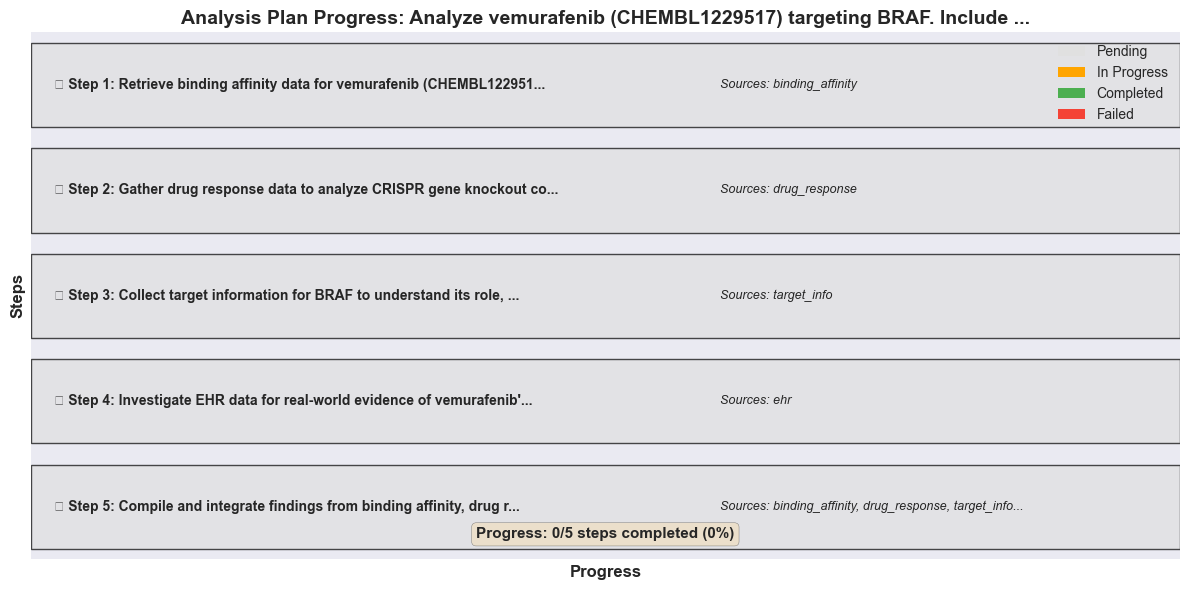


STEP 3: Executing Plan

EXECUTING ANALYSIS PLAN
Query: Analyze vemurafenib (CHEMBL1229517) targeting BRAF. Include binding affinity, drug response correlations, and any EHR evidence for disease prevention.
Total steps: 5


Step 1: Retrieve binding affinity data for vemurafenib (CHEMBL1229517) targeting BRAF to assess its binding strength.
Data sources: binding_affinity
  ✓ Found binding affinity: 6.777839183807373
  ✓ Found target binding statistics
  ✅ Step 1 completed

📊 Progress: 1/5 steps completed
  ✅ Step 1: Retrieve binding affinity data for vemurafenib (CHEMBL1229517) targeting BRAF to assess its binding strength.
  ⏳ Step 2: Gather drug response data to analyze CRISPR gene knockout correlations with vemurafenib response, focusing on AUC and IC50 values.
  ⏳ Step 3: Collect target information for BRAF to understand its role, priority score, and associated diseases.
  ⏳ Step 4: Investigate EHR data for real-world evidence of vemurafenib's effectiveness in disease prevention, fo

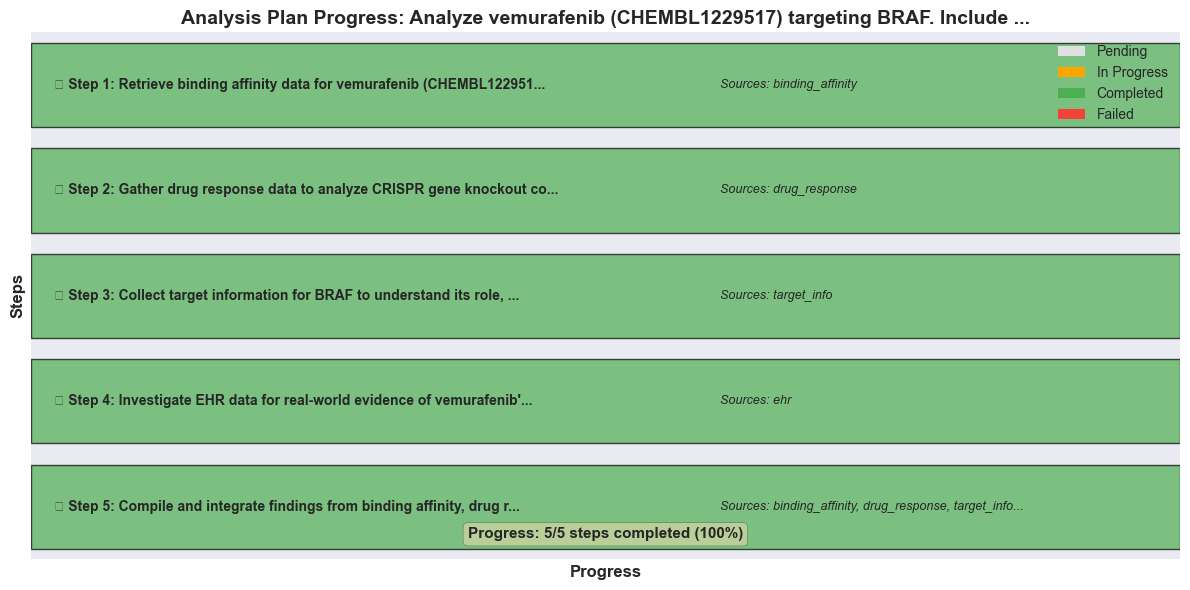


STEP 5: Detailed Results Summary

📋 Step 1: Retrieve binding affinity data for vemurafenib (CHEMBL1229517) targeting BRAF to assess its binding strength.
--------------------------------------------------------------------------------
  • target_binding_stats: Target binding statistics
    - Average pKd: 6.5364
    - Number of drug hits: 11,255
    - TPI: 0.7513

📋 Step 2: Gather drug response data to analyze CRISPR gene knockout correlations with vemurafenib response, focusing on AUC and IC50 values.
--------------------------------------------------------------------------------
  • drug_response: 44 records found
    - Average AUC correlation: 0.4624
    - Average IC50 correlation: nan

📋 Step 3: Collect target information for BRAF to understand its role, priority score, and associated diseases.
--------------------------------------------------------------------------------

📋 Step 5: Compile and integrate findings from binding affinity, drug response, target information, and EHR 

In [44]:
def visualize_plan_progress(plan: AnalysisPlan):
    """Visualize the progress of a plan execution."""
    import matplotlib.pyplot as plt
    import matplotlib.patches as mpatches
    
    fig, ax = plt.subplots(figsize=(12, max(6, len(plan.steps) * 0.8)))
    
    # Color mapping
    status_colors = {
        "pending": "#E0E0E0",
        "in_progress": "#FFA500",
        "completed": "#4CAF50",
        "failed": "#F44336"
    }
    
    # Create progress bars
    y_positions = range(len(plan.steps))
    
    for i, step in enumerate(plan.steps):
        y_pos = len(plan.steps) - i - 1
        color = status_colors.get(step.status, "#E0E0E0")
        
        # Draw bar
        ax.barh(y_pos, 1, color=color, alpha=0.7, edgecolor='black', linewidth=1)
        
        # Add step label
        status_icon = {
            "pending": "⏳",
            "in_progress": "🔄",
            "completed": "✅",
            "failed": "❌"
        }.get(step.status, "❓")
        
        ax.text(0.02, y_pos, f"{status_icon} Step {step.step_number}: {step.description[:60]}...", 
                va='center', fontsize=10, fontweight='bold')
        
        # Add data sources
        sources_text = ", ".join(step.data_sources[:3])
        if len(step.data_sources) > 3:
            sources_text += "..."
        ax.text(0.6, y_pos, f"Sources: {sources_text}", 
                va='center', fontsize=9, style='italic')
    
    ax.set_xlim(0, 1)
    ax.set_ylim(-0.5, len(plan.steps) - 0.5)
    ax.set_xlabel('Progress', fontsize=12, fontweight='bold')
    ax.set_ylabel('Steps', fontsize=12, fontweight='bold')
    ax.set_title(f'Analysis Plan Progress: {plan.query[:60]}...', fontsize=14, fontweight='bold')
    ax.set_yticks([])
    ax.set_xticks([])
    
    # Add legend
    legend_elements = [
        mpatches.Patch(facecolor=status_colors["pending"], label='Pending'),
        mpatches.Patch(facecolor=status_colors["in_progress"], label='In Progress'),
        mpatches.Patch(facecolor=status_colors["completed"], label='Completed'),
        mpatches.Patch(facecolor=status_colors["failed"], label='Failed')
    ]
    ax.legend(handles=legend_elements, loc='upper right')
    
    # Add summary text
    completed = sum(1 for s in plan.steps if s.status == "completed")
    total = len(plan.steps)
    ax.text(0.5, -0.3, f'Progress: {completed}/{total} steps completed ({completed/total*100:.0f}%)', 
            ha='center', fontsize=11, fontweight='bold',
            bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))
    
    plt.tight_layout()
    plt.show()

# Example: Complete workflow - Generate plan, visualize, execute, and show results
if planning_agent:
    # Real query that combines multiple data sources
    test_query = "Analyze vemurafenib (CHEMBL1229517) targeting BRAF. Include binding affinity, drug response correlations, and any EHR evidence for disease prevention."
    
    print("=" * 80)
    print("COMPLETE PLANNING AGENT WORKFLOW DEMONSTRATION")
    print("=" * 80)
    print(f"\nQuery: {test_query}\n")
    
    # Step 1: Generate the plan
    print("STEP 1: Generating analysis plan...")
    print("-" * 80)
    test_plan = planning_agent.generate_plan(test_query)
    
    print(f"\n✓ Generated plan with {len(test_plan.steps)} steps:")
    for step in test_plan.steps:
        print(f"  Step {step.step_number}: {step.description}")
        print(f"    Data sources: {', '.join(step.data_sources)}")
    
    # Step 2: Visualize initial plan (all pending)
    print("\n" + "=" * 80)
    print("STEP 2: Initial Plan Visualization (Before Execution)")
    print("=" * 80)
    visualize_plan_progress(test_plan)
    
    # Step 3: Execute the plan
    print("\n" + "=" * 80)
    print("STEP 3: Executing Plan")
    print("=" * 80)
    test_plan = planning_agent.execute_plan(test_plan, show_progress=True)
    
    # Step 4: Visualize final progress (after execution)
    print("\n" + "=" * 80)
    print("STEP 4: Final Plan Visualization (After Execution)")
    print("=" * 80)
    visualize_plan_progress(test_plan)
    
    # Step 5: Display detailed results
    print("\n" + "=" * 80)
    print("STEP 5: Detailed Results Summary")
    print("=" * 80)
    
    for step in test_plan.steps:
        if step.status == "completed" and step.result:
            print(f"\n📋 Step {step.step_number}: {step.description}")
            print("-" * 80)
            
            for key, value in step.result.items():
                if isinstance(value, dict):
                    if "count" in value:
                        print(f"  • {key}: {value['count']} records found")
                        if "avg_auc_corr" in value and value["avg_auc_corr"]:
                            print(f"    - Average AUC correlation: {value['avg_auc_corr']:.4f}")
                        if "avg_ic50_corr" in value and value["avg_ic50_corr"]:
                            print(f"    - Average IC50 correlation: {value['avg_ic50_corr']:.4f}")
                    elif "overall_strength" in value:
                        print(f"  • {key}: Evidence strength = {value['overall_strength']}")
                        if "sources" in value:
                            for source, data in value["sources"].items():
                                if data.get("found"):
                                    print(f"    - {source}: ✓ Found")
                                    if "binding_affinity" in data:
                                        print(f"      Binding affinity: {data.get('binding_affinity', 'N/A')}")
                                    if "aff_local" in data:
                                        print(f"      aff_local: {data.get('aff_local', 'N/A')}")
                    elif "mount_sinai" in value or "uk_biobank" in value:
                        print(f"  • {key}:")
                        print(f"    - Total associations: {value.get('count', 0)}")
                        print(f"    - Mount Sinai: {value.get('mount_sinai', 0)} records")
                        print(f"    - UK Biobank: {value.get('uk_biobank', 0)} records")
                    elif "Selectivity_Score" in value:
                        print(f"  • {key}: Drug selectivity information")
                        print(f"    - Selectivity Score: {value.get('Selectivity_Score', 'N/A'):.4f}")
                        print(f"    - Drug Type: {value.get('drug_type', 'N/A')}")
                    elif "Avg_pKd" in value:
                        print(f"  • {key}: Target binding statistics")
                        print(f"    - Average pKd: {value.get('Avg_pKd', 'N/A'):.4f}")
                        print(f"    - Number of drug hits: {value.get('N_hit', 'N/A'):,.0f}")
                        print(f"    - TPI: {value.get('TPI', 'N/A'):.4f}")
                elif key == "binding_affinity" and isinstance(value, dict):
                    print(f"  • {key}:")
                    print(f"    - Binding affinity (aff_local): {value.get('binding_affinity', 'N/A'):.4f}")
                    print(f"    - Selectivity Score: {value.get('selectivity_score', 'N/A'):.4f}")
                    print(f"    - Rank: {value.get('rank_select', 'N/A')}")
                else:
                    print(f"  • {key}: {str(value)[:100]}...")
        elif step.status == "failed":
            print(f"\n❌ Step {step.step_number}: {step.description}")
            print(f"   Error: {step.error}")
    
    # Step 6: Show final summary
    if test_plan.summary:
        print("\n" + "=" * 80)
        print("STEP 6: LLM-Generated Analysis Summary")
        print("=" * 80)
        print(test_plan.summary)
    
    print("\n" + "=" * 80)
    print("WORKFLOW COMPLETE")
    print("=" * 80)
    print(f"✓ Plan generated: {len(test_plan.steps)} steps")
    print(f"✓ Steps completed: {sum(1 for s in test_plan.steps if s.status == 'completed')}")
    print(f"✓ Steps failed: {sum(1 for s in test_plan.steps if s.status == 'failed')}")
    print(f"✓ Overall status: {test_plan.overall_status}")
    
else:
    print("Planning agent not available. Set OPENAI_API_KEY to use this feature.")